(02-06-efficiente-markten)=

# Fama en de efficiënte markt

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1965–1970, met uitlopers naar 1978 en 1991.

**Wat we al weten.** In [](#01-02-bachelier) werd de random walk gemeten:
autocorrelaties dicht bij nul, variance ratios net boven één, en steekproeven
die decennia lang moeten zijn om een kleine afwijking te zien. In
[](#01-03-williams-ddm) kwam er een theorie van het prijs*niveau* bij, maar geen
theorie van de prijs*veranderingen*. En in [](#02-05-crsp-tape) kreeg Chicago
de machine: een magneetband met de maandrendementen van elk NYSE-aandeel sinds
1926. Wat ontbrak, was het economische argument dat statistiek en waardering
verbindt.

**Welke vraag staat open.** Wat betekent "de prijs weerspiegelt alle
informatie" precies — en is dat een uitspraak die data kunnen weerleggen?
```

## Overzicht

In januari 1965 verscheen het proefschrift van Eugene Fama als een volledig
nummer van de *Journal of Business*: tweeënzeventig pagina's over de verdeling
en de afhankelijkheid van dagrendementen van de dertig Dow Jones-aandelen
{cite}`Fama1965`. In hetzelfde voorjaar publiceerde Paul Samuelson *Proof that
properly anticipated prices fluctuate randomly* {cite}`Samuelson1965`. Fama
leverde de metingen en het woord, Samuelson het bewijs dat onvoorspelbaarheid
geen eigenschap van de natuur is maar van goed gevormde verwachtingen. In 1970
bracht Fama beide samen in het overzichtsartikel dat het vak twintig jaar lang
zou indelen in toetsen van de zwakke, de semi-sterke en de sterke vorm
{cite}`Fama1970`.

Dat werk definieert het tijdvak omdat het de random walk veranderde van een
statistische curiositeit in een *hypothese over markten en informatie*, met een
onderzoeksprogramma erbij. De epistemische status is ongewoon (motief 3): de
efficiënte-markthypothese is theorie-met-toetsen bij uitstek, maar ze is geen
model van prijzen. Ze is een voorwaarde op hoe een model van verwachte
rendementen met informatie omgaat, en daarom alleen toetsbaar *samen* met zo'n
model — "market efficiency per se is not testable" {cite}`Fama1991`. Die *joint
hypothesis* (gezamenlijke hypothese: elke toets van efficiëntie is tegelijk een
toets van een model van verwachte rendementen) is de draad van deze lecture.

We beginnen met een markt van twee perioden waarin met de hand te zien is dat de
prijs onder risiconeutraliteit een martingaal is en onder risicoaversie niet.
De theorie onderscheidt fair game, martingaal en random walk, bewijst de
stelling van Samuelson, laat zien onder welke maat prijzen wél een martingaal
zijn, en bewijst dat elk patroon van voorspelbaarheid met een passend model van risico te rijmen is.
De simulatie laat een onderzoeker met het verkeerde model "inefficiëntie" vinden
in een volledig rationele economie. De replicatie herhaalt niet de
autocorrelaties en variance ratios van [](#01-02-bachelier), maar de toetsen die
Chicago ertegenover zette: de filterregels van Alexander {cite}`Alexander1961`
en Fama en Blume {cite}`FamaBlume1966`, en kort de fonds-alpha van Jensen
{cite}`Jensen1968`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Fama's eerste definitie was in woorden. Een efficiënte markt is "a market where
there are large numbers of rational profit-maximizers actively competing, with
each trying to predict future market values of individual securities, and where
important current information is almost freely available to all participants";
daarin is "at any point in time the actual price of a security ... a good
estimate of its intrinsic value" {cite}`Fama1965b`. Als veel slimme mensen naar
dezelfde informatie kijken en er geld mee kunnen verdienen, kopen ze tot de
voorspelbare winst weg is. Wat overblijft aan prijsbeweging komt door nieuws, en
nieuws is per definitie wat men nog niet wist.

Er zit een addertje in het woord "winst". Winst ten opzichte van wát? Niemand
houdt een aandeel voor een verwacht rendement van nul; beleggers eisen een
vergoeding voor wachten en voor risico. Stel dat aandelen in slechte tijden
riskanter zijn, of dat beleggers dan minder risico kunnen dragen. Dan dalen de
prijzen in een recessie tot het verwachte rendement hoog genoeg is om iemand over
te halen ze te houden, en is het verwachte rendement na een daling hoger dan na
een stijging. Dat is voorspelbaarheid, en niemand vergist zich: wie na de daling
koopt, verdient meer omdat hij iets draagt wat anderen op dat moment niet willen
dragen.

Of een patroon een inefficiëntie is, hangt dus af van wat het *vereiste*
rendement had moeten zijn. Men kan niet vaststellen of een thermometer afwijkt
zonder te weten welke temperatuur hij had moeten aanwijzen. Verwerpt de data
"efficiëntie plus mijn model van risico", dan weet men niet welk van beide stuk
is.

En er is een paradox: als prijzen alle informatie perfect weerspiegelen, verdient
niemand iets aan het verzamelen ervan, en kan de prijs haar dus ook niet
weerspiegelen {cite}`GrossmanStiglitz1980`. Alexander stipte het in 1961 al aan:
"I leave to the speculation of others the question of what would happen to the
effectiveness of the filter technique if everybody believed in it and operated
accordingly" {cite}`Alexander1961`.

```{note}
Hoe dominant het idee werd, blijkt uit de openingszin van Michael Jensen bij een
themanummer van de *Journal of Financial Economics* in 1978: "I believe there is
no other proposition in economics which has more solid empirical evidence
supporting it than the Efficient Market Hypothesis" {cite}`Jensen1978`. Het
nummer was gewijd aan anomalieën — "evidence which we will not be able to
ignore". Vanaf dat moment werden de hypothese en de barsten erin in één adem
genoemd.
```

## Toy-voorbeeld: één aandeel, twee perioden, één stuk nieuws

Er zijn drie tijdstippen, $t = 0, 1, 2$. Een aandeel betaalt alleen op $t = 2$
een dividend $d_2$. Op $t = 1$ komt publiek nieuws, "goed" of "slecht", elk met
kans $\tfrac12$, en dat bepaalt welke twee dividenden daarna mogelijk zijn, elk
weer met kans $\tfrac12$:

| nieuws op $t=1$ | $d_2$ als het meezit | $d_2$ als het tegenzit | $\E_1[d_2]$ |
|---|---|---|---|
| goed   | 140 | 100 | 120 |
| slecht | 100 |  60 |  80 |

De rente is nul, $R^f = 1$. Het rendement is $R_1 = p_1/p_0$ over de eerste
periode en $R_2 = d_2/p_1$ over de tweede.

**Risiconeutraal.** Beleggers prijzen tegen de verwachte payoff:
$p_1(\text{goed}) = 120$, $p_1(\text{slecht}) = 80$ en
$p_0 = \tfrac12 \cdot 120 + \tfrac12 \cdot 80 = 100$. Dus $\E_0[p_1] = 100 = p_0$:
de prijs is een martingaal, elk verwacht rendement is nul, en niets van wat een
belegger weet helpt hem een hoger rendement te verwachten.

**Risicoavers.** Nu verdisconteren beleggers met een *stochastic discount
factor* (SDF, stochastische disconteringsfactor: de willekeurige variabele
waarmee toekomstige payoffs worden gewogen, $p_t = \E_t[m_{t+1}x_{t+1}]$): in
elke periode $m = 0{,}8$ als het meezit en $m = 1{,}2$ als het tegenzit. Een euro
in een slechte toestand is meer waard; omdat $\E[m] = 1$ blijft de rente nul.
Achterwaarts rekenen:

$$
\begin{aligned}
p_1(\text{goed})   &= \tfrac12(0{,}8)(140) + \tfrac12(1{,}2)(100) = 56 + 60 = 116,\\
p_1(\text{slecht}) &= \tfrac12(0{,}8)(100) + \tfrac12(1{,}2)(60)  = 40 + 36 = 76,\\
p_0                &= \tfrac12(0{,}8)(116) + \tfrac12(1{,}2)(76)  = 46{,}4 + 45{,}6 = 92.
\end{aligned}
$$

Nu is $\E_0[p_1] = \tfrac12(116 + 76) = 96 \neq 92$. De prijs is geen martingaal:
het verwachte rendement over de eerste periode is $96/92 - 1 = 4{,}35\%$ bij een
rente van nul. Op $t = 1$ is het na goed nieuws $120/116 - 1 = 3{,}45\%$ en na
slecht nieuws $80/76 - 1 = 5{,}26\%$. Het verwachte rendement *hangt af van
publieke informatie* en is hoger na een koersdaling. Een onderzoeker die een
constant verwacht rendement aanneemt, ziet een patroon — koop na een daling — en
noemt het een inefficiëntie. Niemand vergist zich echter: na slecht nieuws is
het aandeel riskanter ten opzichte van zijn prijs (een spreiding van 40 op 76,
tegen 40 op 116), en die hogere vergoeding is wat de SDF voorschrijft.

Wél een martingaal is de met de SDF gewogen prijs:
$\E_0[m_1 p_1] = \tfrac12(0{,}8)(116) + \tfrac12(1{,}2)(76) = 92 = p_0$. Of,
equivalent: geef "meezitten" gewicht $q = \tfrac12 \cdot 0{,}8 = 0{,}4$ en
"tegenzitten" $1 - q = 0{,}6$; dan is $0{,}4 \cdot 116 + 0{,}6 \cdot 76 = 92$. De
prijs is een martingaal onder de *juiste maat*, niet onder de werkelijke kansen.
Dat is de joint hypothesis in miniatuur: "de prijs is een martingaal" is waar of
onwaar afhankelijk van welk model van risico men erbij neemt.

In [2]:
prob = 0.5
dividends = {"goed": (140.0, 100.0), "slecht": (100.0, 60.0)}  # (meezitten, tegenzitten)


def price(payoff_up, payoff_down, m=(1.0, 1.0)):
    """One-period price p = E[m x] with two equally likely states."""
    return prob * m[0] * payoff_up + prob * m[1] * payoff_down


columns = {}
for label, m in [("risiconeutraal", (1.0, 1.0)), ("risicoavers", (0.8, 1.2))]:
    p1 = {s: price(*dividends[s], m=m) for s in dividends}
    p0 = price(p1["goed"], p1["slecht"], m=m)
    q_up = prob * m[0] / (prob * m[0] + prob * m[1])       # risk-neutral probability
    columns[label] = {
        "p_1 (goed)": p1["goed"],
        "p_1 (slecht)": p1["slecht"],
        "p_0": p0,
        "E_0[p_1]": prob * (p1["goed"] + p1["slecht"]),
        "E_0[R_1] - 1": prob * (p1["goed"] + p1["slecht"]) / p0 - 1,
        "E_1[R_2] - 1 na goed": np.mean(dividends["goed"]) / p1["goed"] - 1,
        "E_1[R_2] - 1 na slecht": np.mean(dividends["slecht"]) / p1["slecht"] - 1,
        "E_0[m_1 p_1]": price(p1["goed"], p1["slecht"], m=m),
        "E^Q_0[p_1]": q_up * p1["goed"] + (1 - q_up) * p1["slecht"],
    }
toy = pd.DataFrame(columns)

hand = [116.0, 76.0, 92.0, 96.0]
print("handberekening risicoavers klopt:",
      np.allclose(toy["risicoavers"].iloc[:4], hand))
toy.round(4)

handberekening risicoavers klopt: True


,risiconeutraal,risicoavers
p_1 (goed),120.0,116.0000
p_1 (slecht),80.0,76.0000
p_0,100.0,92.0000
E_0[p_1],100.0,96.0000
E_0[R_1] - 1,0.0,0.0435
E_1[R_2] - 1 na goed,0.0,0.0345
E_1[R_2] - 1 na slecht,0.0,0.0526
E_0[m_1 p_1],100.0,92.0000
E^Q_0[p_1],100.0,92.0000


De code reproduceert 116, 76, 92 en 96, de verwachte rendementen van $4{,}35\%$,
$3{,}45\%$ en $5{,}26\%$, en in de laatste twee rijen de 92 die terugkomt zodra men
met de SDF of met de risiconeutrale kansen rekent. In de risiconeutrale kolom
vallen alle martingaalvarianten samen.

## Theorie

### Drie woorden voor onvoorspelbaar

Laat $\mathcal{F}_t$ de publieke informatie op $t$ zijn en
$\E_t[\cdot] = \E[\cdot \mid \mathcal{F}_t]$; Fama schrijft $\Phi_t$ waar wij
$\mathcal{F}_t$ schrijven. De vroege literatuur gebruikte drie begrippen door
elkaar {cite}`Fama1970`.

:::{prf:definition} Fair game, martingaal, random walk
:label: thm-efficiente-markten-begrippen

1. Een rij $z_{t+1}$ is een **fair game** als $\E_t[z_{t+1}] = 0$. Fama past dit
   toe op $z_{t+1} = R_{t+1} - \E_t[R_{t+1}]$: het rendement boven het
   *evenwichts*-verwachte rendement, wat dat ook is.
2. Een prijsreeks is een **martingaal** als $\E_t[p_{t+1}] = p_t$, en een
   **submartingaal** als $\E_t[p_{t+1}] \ge p_t$.
3. Log-rendementen volgen een **random walk** als de $r_{t+1}$ onafhankelijk en
   identiek verdeeld zijn: $f(r_{t+1} \mid \mathcal{F}_t) = f(r_{t+1})$.
:::

*Waarom zou dit waar zijn?* Het zijn steeds zwakkere uitspraken over wat
informatie níet kan. De random walk zegt dat het verleden niets zegt over de
*hele verdeling* van morgen; de martingaal alleen dat het niets zegt over de
*verwachting*; de fair game nog minder: alleen de afwijking van het vereiste
rendement is onvoorspelbaar, en het vereiste rendement mag zelf bewegen.

:::{prf:proposition} Hiërarchie
:label: thm-efficiente-markten-hierarchie

(i) Is $r_{t+1}$ i.i.d. met verwachting $\mu$, dan is $z_{t+1} = r_{t+1} - \mu$
een fair game. (ii) Elke fair game met eindige variantie is ongecorreleerd met
elke functie $g$ van $\mathcal{F}_t$; in het bijzonder zijn de autocorrelaties
nul. (iii) Het omgekeerde van (i) geldt niet.
:::

:::{prf:proof}
(i) Onafhankelijkheid geeft $\E_t[r_{t+1}] = \mu$. (ii) Met herhaalde
verwachtingen is $\E[z_{t+1} g] = \E\left[g\, \E_t[z_{t+1}]\right] = 0$ en
$\E[z_{t+1}] = 0$; kies $g = z_{t+1-k}$ voor de autocorrelatie van orde $k$.
(iii) Neem $z_{t+1} = \sigma_t \varepsilon_{t+1}$ met $\varepsilon$ i.i.d.
standaardnormaal en $\sigma_t^2 = \omega + \alpha z_t^2$. Dan is
$\E_t[z_{t+1}] = 0$, maar $\Var_t(z_{t+1}) = \sigma_t^2$ hangt van $z_t$ af.
$\square$
:::

Het tegenvoorbeeld is de werkelijkheid: volatiliteit clustert
([](#04-21-volatiliteit)). Het maakt duidelijk wat de toetsen van
[](#01-02-bachelier) toetsten: autocorrelaties en variance ratios gaan over
eerste en tweede momenten, en zijn dus toetsen van de fair game ten opzichte van
de prijsgeschiedenis, niet van onafhankelijkheid — daarom was daar de
heteroskedasticiteitsrobuuste $z_2$ de relevante grootheid. Fama stelde in 1970
vast dat de extra aanname van onafhankelijkheid vanuit de theorie van efficiënte
markten "superfluous" was {cite}`Fama1970`.

### De stelling van Samuelson

*Waarom zou dit waar zijn?* Een termijnprijs is de beste schatting die de markt
vandaag heeft van de spotprijs op de leverdatum. Als de verandering naar de
schatting van morgen vandaag al voorspelbaar was, was de schatting van vandaag
niet de beste geweest. Alleen wat men morgen leert en vandaag niet wist, kan de
schatting nog verplaatsen.

Samuelson formuleerde het voor een contract dat op $T$ de spotprijs $S_T$
uitbetaalt, bij een rente van nul en zonder risicopremie {cite}`Samuelson1965`.

:::{prf:theorem} Samuelson (1965)
:label: thm-efficiente-markten-samuelson

Laat $S_T$ integreerbaar zijn en $F_t = \E_t[S_T]$ voor $t \le T$. Dan geldt,
*ongeacht* het proces dat $S$ genereert:

```{math}
:label: eq-efficiente-markten-samuelson
\E_t[F_{t+1}] = F_t,
\qquad
\Cov\!\left(F_{t+1} - F_t,\; g(\mathcal{F}_t)\right) = 0
\quad\text{voor elke } g .
```
:::

:::{prf:proof}
Omdat $\mathcal{F}_t \subseteq \mathcal{F}_{t+1}$ geeft de wet van herhaalde
verwachtingen $\E_t[F_{t+1}] = \E_t\!\left[\E_{t+1}[S_T]\right] = \E_t[S_T] = F_t$.
Het tweede deel volgt uit {prf:ref}`thm-efficiente-markten-hierarchie` (ii).
$\square$
:::

Er is niets aangenomen over de spotprijs; die mag volkomen voorspelbaar zijn.
Volgt ze een AR(1), $S_{t+1} = \phi S_t + \varepsilon_{t+1}$, dan is
$F_t = \phi^{T-t} S_t$ en

```{math}
:label: eq-efficiente-markten-ar1
F_{t+1} - F_t = \phi^{T-t-1}\left(S_{t+1} - \phi S_t\right)
             = \phi^{T-t-1}\,\varepsilon_{t+1} .
```

De termijnprijs beweegt met de *schok*, niet met de spotprijsverandering, en zijn
variantie $\phi^{2(T-t-1)}\sigma^2$ *stijgt* naarmate de leverdatum nadert: ver
van $T$ dempt de terugkeer naar het gemiddelde elke schok, dichtbij niet meer.
Die voorspelling staat bekend als het Samuelson-effect. De cel hieronder
simuleert het met $\phi = 0{,}5$, een spotprijs waarvan een kwart van de
variantie van de verandering voorspelbaar is.

In [3]:
phi, horizon, n_paths = 0.5, 12, 20_000
spot = np.empty((n_paths, horizon + 1))
spot[:, 0] = rng.normal(0.0, 1.0 / np.sqrt(1 - phi**2), n_paths)  # stationary start
for t in range(1, horizon + 1):
    spot[:, t] = phi * spot[:, t - 1] + rng.normal(0.0, 1.0, n_paths)
futures = phi ** (horizon - np.arange(horizon + 1)) * spot       # F_t = E_t[S_T]


def pooled_slope(y, x):
    """Pooled OLS slope of y on x after demeaning both."""
    x, y = x.ravel() - x.mean(), y.ravel() - y.mean()
    return float(x @ y / (x @ x))


pd.DataFrame(
    {
        "helling op S_t (simulatie)": [
            pooled_slope(np.diff(spot, axis=1), spot[:, :-1]),
            pooled_slope(np.diff(futures, axis=1), spot[:, :-1]),
        ],
        "helling op S_t (theorie)": [phi - 1, 0.0],
    },
    index=["spot: S_{t+1} - S_t", "termijn: F_{t+1} - F_t"],
).round(3)

,helling op S_t (simulatie),helling op S_t (theorie)
spot: S_{t+1} - S_t,-0.500,-0.5
termijn: F_{t+1} - F_t,-0.001,0.0


In [4]:
steps = np.arange(horizon)
pd.DataFrame(
    {
        "Var(F_{t+1} - F_t) simulatie": np.diff(futures, axis=1).var(axis=0),
        "phi^(2(T-t-1)) theorie": phi ** (2 * (horizon - steps - 1)),
    },
    index=pd.Index(steps, name="t"),
).iloc[[0, 6, 9, 10, 11]].round(4)

,Var(F_{t+1} - F_t) simulatie,phi^(2(T-t-1)) theorie
t,,
0,0.0000,0.0000
6,0.0010,0.0010
9,0.0621,0.0625
10,0.2512,0.2500
11,1.0202,1.0000


De spotprijsverandering heeft op de spotprijs een helling van $-0{,}5$, precies
$\phi - 1$; de termijnprijsverandering een helling van nul. De variantie van de
termijnprijsverandering loopt op van vrijwel niets een jaar voor levering naar
één in de laatste periode, zoals [](#eq-efficiente-markten-ar1) voorschrijft.

### Martingaal onder de juiste maat

*Waarom zou dit waar zijn?* Een aandeel is geen termijncontract: wie het koopt,
legt vandaag geld op tafel en draagt risico, en moet gemiddeld beloond worden.
Die beloning is precies wat de SDF uitdrukt. Haal haar eruit door de payoffs met
de SDF te wegen, en wat overblijft moet weer onvoorspelbaar zijn.

Voor elk activum met dividenden $d_t$ geldt

```{math}
:label: eq-efficiente-markten-pricing
p_t = \E_t\!\left[m_{t+1}\left(p_{t+1} + d_{t+1}\right)\right],
\qquad
\frac{1}{R^{f}_{t+1}} = \E_t[m_{t+1}] .
```

:::{prf:theorem} Martingaal na verdiscontering
:label: thm-efficiente-markten-martingaal

Laat [](#eq-efficiente-markten-pricing) gelden met $m_{t+1} > 0$. Definieer
$\Lambda_0 = 1$, $\Lambda_{t} = \prod_{s=1}^{t} m_s$ en
$G_t = \Lambda_t p_t + \sum_{s=1}^{t} \Lambda_s d_s$. Dan

1. is $G_t$ een martingaal onder de werkelijke kansen $P$;
2. bestaat er een maat $Q$, met eenstapsdichtheid
   $\left.\mathrm{d}Q/\mathrm{d}P\right|_{t+1} = m_{t+1} R^{f}_{t+1}$, waaronder
   $\E^{Q}_t\!\left[(p_{t+1} + d_{t+1})/R^{f}_{t+1}\right] = p_t$;
3. is het verwachte excess rendement onder $P$

```{math}
:label: eq-efficiente-markten-premie
\E_t\!\left[R_{t+1}\right] - R^{f}_{t+1}
= -R^{f}_{t+1}\,\Cov_t\!\left(m_{t+1}, R_{t+1}\right).
```
:::

:::{prf:proof}
(1) $G_{t+1} - G_t = \Lambda_t\left[m_{t+1}(p_{t+1} + d_{t+1}) - p_t\right]$, en
omdat $\Lambda_t$ op $t$ bekend is, is de conditionele verwachting nul door
[](#eq-efficiente-markten-pricing).
(2) $\xi_{t+1} = m_{t+1}R^{f}_{t+1}$ is positief met $\E_t[\xi_{t+1}] = 1$, dus
een kansdichtheid, en
$\E^{Q}_t\!\left[(p_{t+1}+d_{t+1})/R^{f}_{t+1}\right]
= \E_t\!\left[m_{t+1}(p_{t+1}+d_{t+1})\right] = p_t$.
(3) Deel [](#eq-efficiente-markten-pricing) door $p_t$:
$1 = \E_t[m_{t+1}]\E_t[R_{t+1}] + \Cov_t(m_{t+1},R_{t+1})$; vermenigvuldig met
$R^{f}_{t+1}$ en herschik. $\square$
:::

Deel 3 is de reden dat de prijs in het toy-voorbeeld geen martingaal was: op
$t = 0$ is $\Cov_0(m_1, R_1) = \E_0[m_1R_1] - \E_0[m_1]\E_0[R_1] = 1 - 1{,}0435$, een
premie van $4{,}35\%$. Zodra de conditionele covariantie met de SDF beweegt,
beweegt het verwachte rendement mee. LeRoy liet in 1973 zien dat risicoaversie
de martingaaleigenschap van aandelenprijzen in het algemeen breekt
{cite}`LeRoy1973`, en Lucas gaf er in 1978 het evenwichtsmodel bij
{cite}`Lucas1978`. Deel 2 is de voorloper van de stelling van Harrison en Kreps
{cite}`HarrisonKreps1979`: zo'n $Q$ bestaat precies als er geen arbitrage is
([](#03-11-apt-no-arbitrage)).

### Waarom voorspelbaarheid geen inefficiëntie hoeft te zijn

*Waarom zou dit waar zijn?* Als een tijdvariërend verwacht rendement niets anders
is dan een tijdvariërende prijs van risico, dan moet men elk voorspelbaar patroon
kunnen "verklaren" met een SDF die precies dat patroon beloont. De enige grens is
dat de SDF positief moet blijven; een negatieve prijs voor een positieve payoff
is een gratis lunch.

:::{prf:proposition} Elk patroon heeft een SDF
:label: thm-efficiente-markten-elke-sdf

Laat $R^{e}_{t+1}$ een excess rendement zijn met conditionele verwachting $\mu_t$
en conditionele variantie $\sigma_t^2 > 0$, beide willekeurige functies van
$\mathcal{F}_t$. Dan prijst

```{math}
:label: eq-efficiente-markten-sdf
m_{t+1} = \frac{1}{R^{f}_{t+1}}
\left[1 - \frac{\mu_t}{\sigma_t^2}\left(R^{e}_{t+1} - \mu_t\right)\right]
```

zowel de risicovrije belegging als het excess rendement:
$\E_t[m_{t+1}]R^{f}_{t+1} = 1$ en $\E_t[m_{t+1}R^{e}_{t+1}] = 0$. De SDF is
positief zolang $\left|\mu_t\left(R^{e}_{t+1} - \mu_t\right)\right| < \sigma_t^2$,
en $\SD_t(m_{t+1})/\E_t[m_{t+1}] = |\mu_t|/\sigma_t$, de conditionele
Sharpe-ratio.
:::

:::{prf:proof}
$\E_t[R^{e}_{t+1} - \mu_t] = 0$ geeft $\E_t[m_{t+1}] = 1/R^{f}_{t+1}$, en
$R^{f}_{t+1}\E_t[m_{t+1}R^{e}_{t+1}]
= \mu_t - \frac{\mu_t}{\sigma_t^2}\E_t\!\left[(R^{e}_{t+1}-\mu_t)R^{e}_{t+1}\right]
= \mu_t - \mu_t = 0$. Positiviteit en volatiliteit volgen direct uit
[](#eq-efficiente-markten-sdf). $\square$
:::

Dit is de joint hypothesis in haar scherpste vorm. Hangt $\E_t[R^{e}_{t+1}]$ af
van het dividendrendement, van het rendement van vorige maand of van het weer in
New York, er is altijd een SDF die dat als rationele risicopremie prijst.
"Efficiënt" legt zonder model geen beperking op rendementen op, zolang er geen
arbitrage is. Fama schreef in 1970: "The definitional statement that in an
efficient market prices 'fully reflect' available information is so general that
it has no empirically testable implications" {cite}`Fama1970`; in 1991: "market
efficiency per se is not testable. It must be tested jointly with some model of
equilibrium, an asset-pricing model" {cite}`Fama1991`.

Toetsbaar wordt het pas als men iets over $m_{t+1}$ zegt: dat hij positief is
(een grens aan de voorspelbare Sharpe-ratio), dat hij hoog is in slechte tijden
en dus met consumptie samenhangt ([](#03-12-consumptie-capm)), en dat zijn
volatiliteit geloofwaardig is — de grens van Hansen en Jagannathan
{cite}`HansenJagannathan1991` die de equity premium tot puzzel maakt
([](#03-13-equity-premium-puzzle)).

```{warning}
De joint hypothesis snijdt naar twee kanten. Een positieve alpha ten opzichte van
het CAPM kan betekenen dat de markt inefficiënt is, of dat het CAPM fout is. Géén
alpha kan betekenen dat de markt efficiënt is, of dat de toets te zwak is — en de
simulatie hieronder laat zien hoe zwak zulke toetsen zijn.
```

### Wat een filterregel toetst

*Waarom zou dit waar zijn?* De filterregel omzeilt de joint hypothesis
gedeeltelijk. Hij vraagt niet of het verwachte rendement constant is, maar of een
handelaar die op basis van de prijsgeschiedenis in en uit springt méér verwacht
rendement haalt dan wie het aandeel vasthoudt. Zolang het verwachte excess
rendement nooit negatief is, kan dat niet: uitstappen betekent alleen een
niet-negatieve premie laten liggen.

:::{prf:proposition} Submartingaal en handelsregels
:label: thm-efficiente-markten-filter

Laat $\E_t[R^{e}_{t+1}] \ge 0$ voor elke $t$, en $w_t \in [-1, 1]$ een positie
die alleen van $\mathcal{F}_t$ afhangt (lang, kas of short). Dan is
$\E[w_t R^{e}_{t+1}] \le \E[R^{e}_{t+1}]$.
:::

:::{prf:proof}
$\E[w_t R^{e}_{t+1}] = \E\!\left[w_t\,\E_t[R^{e}_{t+1}]\right]
\le \E\!\left[\E_t[R^{e}_{t+1}]\right] = \E[R^{e}_{t+1}]$, omdat $w_t \le 1$ en
$\E_t[R^{e}_{t+1}] \ge 0$. $\square$
:::

Dit is Fama's submartingaal (zijn vergelijking 6), die volgens hem handelsregels
uitsluit die "have greater expected profits than a policy of always
buying-and-holding the security" {cite}`Fama1970`. De vergelijking gaat over
verwachte rendementen, niet over risico, en de aanname $\E_t[R^{e}] \ge 0$ is zelf
een stukje model. Maar het is een veel zwakker model dan "constant verwacht
rendement", en dat maakte de filterregel tot de favoriete toets van Chicago.

### De drie vormen, en de definitie van Jensen

Fama's overzicht opent met: "A market in which prices always 'fully reflect'
available information is called 'efficient'" {cite}`Fama1970`. Omdat "alle
informatie" te vaag is, deelde hij de toetsen in naar de informatieverzameling —
een onderscheid dat hij in een voetnoot aan Harry Roberts toeschreef.

| vorm | informatieverzameling | typische toets | in deze reeks |
|---|---|---|---|
| zwak | de prijsgeschiedenis | autocorrelaties, variance ratios, filterregels | [](#01-02-bachelier), hier |
| semi-sterk | alle publieke informatie | event studies | [](#02-07-event-studies) |
| sterk | ook "monopolistic access" tot informatie | fondsen, insiders | hier kort, [](#04-25-industrie) |

Zijn conclusie: "no important evidence against the hypothesis in the weak and
semi-strong form tests ... and only limited evidence against the hypothesis in
the strong form tests" {cite}`Fama1970`. In 1991 hernoemde hij de categorieën tot
toetsen van voorspelbaarheid van rendementen, event studies en toetsen van
private informatie {cite}`Fama1991`. Jensen maakte in 1978 kosten en risico
expliciet.

:::{prf:definition} Efficiëntie volgens Jensen (1978)
:label: thm-efficiente-markten-jensen

"A market is efficient with respect to information set $\theta_t$ if it is
impossible to make economic profits by trading on the basis of information set
$\theta_t$", met "economic profits" als "the risk adjusted returns net of all
costs" {cite}`Jensen1978`.
:::

Jensens voetnoot geeft de wiskundige vorm,
$\E(P_{t+1} \mid \theta_t) = P_t(1 + \rho_t)$, met $\rho_t$ het *vereiste*
rendement: de joint hypothesis in één symbool. En "net of all costs" maakt een
markt waarin een *floor trader* (handelaar op de beursvloer zonder makelaarscommissie) bruto verdient maar het aan clearingkosten kwijt
is, per definitie efficiënt — de reden dat de filterregels hieronder op twee
manieren worden gerapporteerd.

### De paradox van Grossman en Stiglitz

*Waarom zou dit waar zijn?* Informatie verzamelen kost geld. Wie die kosten maakt,
moet iets terugkrijgen, en dat kan alleen als de prijs de informatie nog niet
volledig weerspiegelt. Een perfect efficiënte markt kan dus geen evenwicht zijn
als informatie kosten heeft.

Grossman en Stiglitz formaliseerden dit met een fractie $\lambda$ geïnformeerde
beleggers die een kostprijs $c$ betalen voor een signaal, en ruis in het aanbod
die voorkomt dat de prijs het signaal volledig verraadt
{cite}`GrossmanStiglitz1980`. In evenwicht is $\lambda$ zo groot dat geïnformeerd
en ongeïnformeerd beleggen na aftrek van $c$ even aantrekkelijk zijn; zolang
$c > 0$ wordt de prijs nooit volledig informatief. Met Jensens "net of all costs"
is dat te verzoenen: bruto is er winst, netto niet. Wat er gebeurt als informatie
bijna gratis wordt, is de vraag van [](#07-37-llms-en-efficientie).

## Simulatie: een rationele economie en een onderzoeker met het verkeerde model

Nu het toy-voorbeeld op schaal: hoe lang moet een onderzoeker met een
constant-rendementmodel kijken voordat hij in een rationele economie
"inefficiëntie" vindt? Het maandelijkse excess rendement is

$$
R^{e}_{t+1} = \mu + x_t + \sigma\,\varepsilon_{t+1},
\qquad
x_{t+1} = \phi\, x_t + \eta_{t+1},
$$

met $\mu = 0{,}6\%$, $\sigma = 4{,}5\%$, $\phi = 0{,}98$ en een onvoorwaardelijke
standaarddeviatie van $x_t$ van $0{,}3\%$ per maand. Het verwachte rendement
schommelt dus met ongeveer $3{,}6\%$ op jaarbasis rond $7{,}2\%$ — de orde van
grootte die [](#04-20-voorspelbaarheid) in de data vindt. De schokken $\varepsilon$
en $\eta$ zijn onafhankelijk, zodat er geen Stambaugh-bias is.

De economie is rationeel: de SDF uit [](#eq-efficiente-markten-sdf), met
$R^f = 1$, prijst het rendement in elke periode exact, en een hoge $x_t$ is een
hoge prijs van risico. De onderzoeker observeert $x_t$ — denk aan het
dividendrendement — en toetst $H_0\colon \E_t[R^{e}_{t+1}] = \text{constant}$ met
de regressie $R^{e}_{t+1} = a + b\,x_t + u_{t+1}$. Een tweede onderzoeker kent het
juiste model en regresseert het abnormale rendement $R^{e}_{t+1} - \mu_t$ op
dezelfde $x_t$.

In [5]:
months, n_sim = 1800, 2000             # 150 jaar maanddata, 2000 economieën
mu, sigma, phi_x, sd_x = 0.006, 0.045, 0.98, 0.003

x_state = np.empty((n_sim, months))
x_state[:, 0] = rng.normal(0.0, sd_x, n_sim)
eta = rng.normal(0.0, sd_x * np.sqrt(1 - phi_x**2), (n_sim, months))
for t in range(1, months):
    x_state[:, t] = phi_x * x_state[:, t - 1] + eta[:, t]
expected = mu + x_state                                   # E_t[R^e_{t+1}]
excess = expected + rng.normal(0.0, sigma, (n_sim, months))  # column t: earned t -> t+1
sdf = 1.0 - (expected / sigma**2) * (excess - expected)     # proposition, R^f = 1

r2_population = sd_x**2 / (sd_x**2 + sigma**2)
pd.Series(
    {
        "gemiddelde m * R^e (moet 0 zijn)": np.mean(sdf * excess),
        "gemiddelde m (moet 1 zijn)": sdf.mean(),
        "fractie m < 0": np.mean(sdf < 0),
        "populatie-R^2 van de voorspelregressie": r2_population,
        "SD van E_t[R^e] op jaarbasis": 12 * expected.std(),
    }
).round(5)

gemiddelde m * R^e (moet 0 zijn)         -0.00002
gemiddelde m (moet 1 zijn)                1.00008
fractie m < 0                             0.00001
populatie-R^2 van de voorspelregressie    0.00442
SD van E_t[R^e] op jaarbasis              0.03598
dtype: float64

De SDF prijst het rendement tot op de simulatieruis, is gemiddeld één, en is in
slechts één op de honderdduizend gesimuleerde maanden negatief, bij schokken van
meer dan zes standaarddeviaties. De populatie-$R^2$ van de voorspelregressie is
$0{,}44\%$, en dat getal bepaalt alles wat volgt.

In [6]:
def slope_tstats(y, x):
    """Row-wise OLS slope t-statistics of y on x (homoskedastic standard errors)."""
    T = y.shape[1]
    xd = x - x.mean(axis=1, keepdims=True)
    yd = y - y.mean(axis=1, keepdims=True)
    sxx = (xd**2).sum(axis=1)
    slope = (xd * yd).sum(axis=1) / sxx
    resid = yd - slope[:, None] * xd
    return slope / np.sqrt((resid**2).sum(axis=1) / (T - 2) / sxx)


rows, t_at_100 = [], {}
for years in (10, 25, 50, 75, 100, 150):
    T = 12 * years
    t_const = slope_tstats(excess[:, :T], x_state[:, :T])
    t_true = slope_tstats(excess[:, :T] - expected[:, :T], x_state[:, :T])
    drift = np.sqrt(T * r2_population / (1 - r2_population))
    rows.append(
        {
            "jaren": years,
            "verwerpt constant model": np.mean(np.abs(t_const) > 1.96),
            "analytisch": stats.norm.sf(1.96 - drift) + stats.norm.cdf(-1.96 - drift),
            "verwerpt juiste model": np.mean(np.abs(t_true) > 1.96),
        }
    )
    if years == 100:
        t_at_100 = {"constant model": t_const, "juiste model": t_true}
power = pd.DataFrame(rows).set_index("jaren")
power.round(3)

,verwerpt constant model,analytisch,verwerpt juiste model
jaren,,,
10,0.077,0.113,0.056
25,0.166,0.211,0.052
50,0.318,0.372,0.038
75,0.456,0.516,0.047
100,0.600,0.637,0.046
150,0.790,0.807,0.048


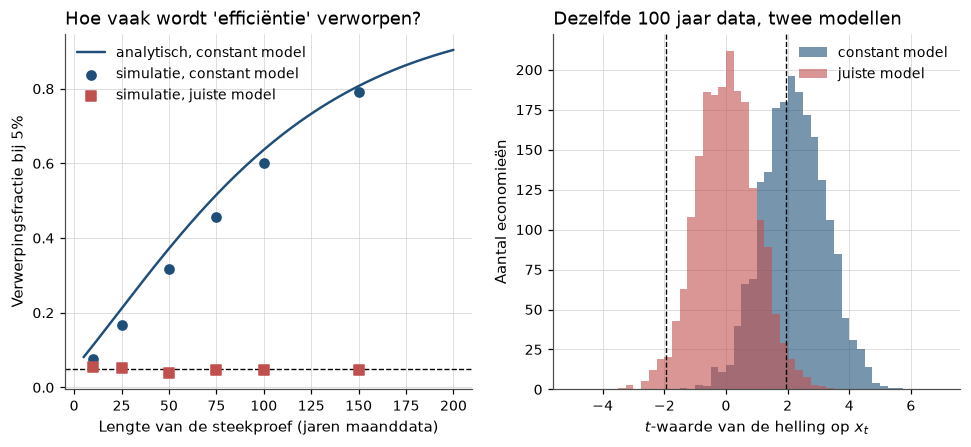

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))

grid = np.linspace(5, 200, 200)
drift = np.sqrt(12 * grid * r2_population / (1 - r2_population))
axes[0].plot(grid, stats.norm.sf(1.96 - drift) + stats.norm.cdf(-1.96 - drift),
             color=hap.plotting.COLORS[0], label="analytisch, constant model")
axes[0].scatter(power.index, power["verwerpt constant model"],
                color=hap.plotting.COLORS[0], zorder=3, label="simulatie, constant model")
axes[0].scatter(power.index, power["verwerpt juiste model"],
                color=hap.plotting.COLORS[1], marker="s", zorder=3,
                label="simulatie, juiste model")
axes[0].axhline(0.05, color="black", lw=0.9, ls="--")
axes[0].set_title("Hoe vaak wordt 'efficiëntie' verworpen?")
axes[0].set_xlabel("Lengte van de steekproef (jaren maanddata)")
axes[0].set_ylabel("Verwerpingsfractie bij 5%")
axes[0].legend()

bins = np.linspace(-5, 7, 49)
for i, (name, tvals) in enumerate(t_at_100.items()):
    axes[1].hist(tvals, bins=bins, alpha=0.6, color=hap.plotting.COLORS[i], label=name)
for c in (-1.96, 1.96):
    axes[1].axvline(c, color="black", lw=0.9, ls="--")
axes[1].set_title("Dezelfde 100 jaar data, twee modellen")
axes[1].set_xlabel("$t$-waarde van de helling op $x_t$")
axes[1].set_ylabel("Aantal economieën")
axes[1].legend()
plt.show()

:::{figure} #cel-efficiente-markten-power
:label: fig-efficiente-markten-power
:width: 95%

Links: de kans dat een onderzoeker een constant verwacht rendement verwerpt in
een economie die volledig rationeel is. Na een eeuw maanddata lukt dat in
ongeveer zes op de tien steekproeven; wie het juiste model kent, verwerpt in vijf
procent van de gevallen, de omvang van de toets. Rechts: voor dezelfde honderd
jaar data ligt de $t$-waarde onder het constante model naar rechts verschoven,
onder het juiste model rond nul. De data zijn gelijk; alleen het model verschilt.
:::

De figuur toont twee motieven tegelijk. Eerst motief 2: de onderzoeker met het
constante model vindt in honderd jaar data in zestig procent van de economieën
"inefficiëntie", terwijl er per constructie niets inefficiënts gebeurt, en de
onderzoeker met het juiste model ziet in dezelfde data een fair game. Hun
meningsverschil gaat niet over de data maar over $m_{t+1}$.

Dan motief 1. Met kleine $R^2$ is de verwachte $t$-waarde ongeveer $\sqrt{T R^2}$,
dus zijn er

```{math}
:label: eq-efficiente-markten-steekproef
T^{*} \approx \frac{1{,}96^{2}}{R^{2}} \approx \frac{3{,}84}{0{,}0044} \approx 870
\text{ maanden}
```

nodig — ruim tweeënzeventig jaar — om de toets gemiddeld nét significant te
krijgen, wat pas vijftig procent kans op verwerping geeft; voor tachtig procent is
$(1{,}96 + 0{,}84)^2/R^2 \approx 1780$ maanden nodig, bijna honderdvijftig jaar.
Een variatie in het verwachte rendement van $3{,}6$ procentpunt per jaar is
economisch enorm en statistisch vrijwel onzichtbaar: de standaardfout van 2%,
toegepast op een gemiddelde dat in de tijd beweegt. De simulatie ligt overal
enkele procentpunten onder de formule, omdat een persistente $x_t$ in een eindige
steekproef minder spreiding rond haar steekproefgemiddelde heeft dan in de
populatie; het verschil krimpt van ruim vier punten bij vijfentwintig jaar tot
minder dan twee bij honderdvijftig.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Eugene F. Fama en Marshall E. Blume, *Filter Rules and Stock-Market
Trading*, Journal of Business 1966 {cite}`FamaBlume1966`, als antwoord op Sidney
Alexander, *Price Movements in Speculative Markets: Trends or Random Walks*,
Industrial Management Review 1961 {cite}`Alexander1961`.

**Wat.** Fama en Blume, tabel 3: het gemiddelde jaarrendement per aandeel van
filters van 0,5% tot 50% op de dertig Dow Jones-aandelen, met dividenden, van
ongeveer eind 1957 tot 26 september 1962. Voor het 0,5%-filter: $0{,}1152$ vóór
commissies tegen $0{,}0986$ voor buy-and-hold, $-1{,}0359$ ná commissies, 12 514
transacties. Alexander, tabel 7: een 5%-filter op de Dow Jones en S&P
Industrials verdiende vóór commissies $20{,}5\%$ per jaar (1897–1914), $15{,}8\%$
(1914–1929) en $36{,}8\%$ (1929–1959), tegen $3{,}2\%$, $14{,}1\%$ en $3{,}0\%$
voor buy-and-hold.

**Data hier.** De dagelijkse Amerikaanse marktportefeuille van Kenneth French,
1926-07 t/m 2026-07 (`hap.data.market_daily()`); de verhandelbare ETF SPY,
1993–2026 (`hap.data.yahoo(...)`); en voor Alexander de maandreeks van Shiller
(`hap.data.shiller()`) naast de maandelijkse French-markt.

**Verschil met het origineel.** Fama en Blume gebruikten dertig individuele
aandelen; wij passen dezelfde regel toe op een *index*. Naast hun volledige
commissies rekenen wij met hun alternatief van $0{,}1\%$ per transactie, de
clearingkosten die ook een floor trader niet ontliep. Alexander gebruikte
dagelijkse slotkoersen zonder dividenden; Shiller heeft alleen maandgemiddelden,
en die zijn hier juist daarom interessant.

**Verwachte afwijking.** De indexgetallen kunnen die van Fama en Blume niet
reproduceren; de falsifieerbare verwachting zit in de *richting*. Fama en Blume
voorspelden in hun voetnoot 3 dat een index door niet-synchrone handel meer
positieve afhankelijkheid vertoont dan de aandelen erin. Op de index moet het
0,5%-filter vóór kosten dus ruimer boven buy-and-hold uitkomen dan hun
$1{,}7$ procentpunt, en die voorsprong moet over deelperiodes de rangorde van de
eerste autocorrelatie van dagrendementen volgen. Op de verhandelbare SPY mag
geen klein filter buy-and-hold verslaan. En een filter op Shillers
maandgemiddelden moet beter presteren dan op maandeindkoersen.
```

De regel is die van Alexander, in de vorm van Fama en Blume: stijgt de slotkoers
$x$ procent boven een eerder dal, ga lang; daalt hij $x$ procent onder een eerdere
top, verkoop en ga short. Wij rekenen met de totaalrendementsindex, zodat de
lange positie dividenden ontvangt en de short positie ze betaalt — de correctie
die Fama en Blume tegen Alexander inbrachten. Rendementen zijn gemiddelde
log-rendementen maal 252.

In [8]:
def filter_positions(level, x):
    """Alexander filter as in Fama-Blume: +1 long, -1 short, 0 before the first signal."""
    level = np.asarray(level, float)
    positions = np.zeros(len(level))
    state, start, peak, trough = 0, level[0], level[0], level[0]
    for t, p in enumerate(level):
        if state == 0:
            if p >= start * (1 + x):
                state, peak = 1, p
            elif p <= start * (1 - x):
                state, trough = -1, p
        elif state == 1:
            peak = max(peak, p)
            if p <= peak * (1 - x):
                state, trough = -1, p
        else:
            trough = min(trough, p)
            if p >= trough * (1 + x):
                state, peak = 1, p
        positions[t] = state
    return positions


def filter_performance(returns, x, cost=0.001, periods=252):
    """Annualised log return of an x-filter, before and after a cost per transaction."""
    held = pd.Series(filter_positions((1 + returns).cumprod(), x), index=returns.index)
    held = held.shift(1).fillna(0.0)                   # position at close t earns t+1
    first = held.ne(0).idxmax()
    held, r = held.loc[first:], returns.loc[first:]
    gross = np.log1p(held * r)
    switches = held.diff().fillna(0.0).ne(0)
    return {
        "filter": x,
        "voor kosten": periods * gross.mean(),
        "na 0,1% per transactie": periods * (gross - cost * switches).mean(),
        "buy-and-hold": periods * np.log1p(r).mean(),
        "transacties per jaar": switches.sum() / (len(r) / periods),
    }


market = hap_data.market_daily()["Mkt"]
filters = (0.005, 0.01, 0.015, 0.02, 0.03, 0.05, 0.10, 0.20)
fama_blume_window = market.loc["1957-12":"1962-09-26"]
ours = pd.DataFrame([filter_performance(fama_blume_window, x) for x in filters]).set_index("filter")

published = pd.DataFrame(
    {
        "FB voor commissies": [0.1152, 0.0547, 0.0277, 0.0023, -0.0169, -0.0188, 0.0298, 0.0428],
        "FB na commissies": [-1.0359, -0.7494, -0.5614, -0.4515, -0.3049, -0.1662, -0.0143, 0.0298],
    },
    index=pd.Index(filters, name="filter"),
)
pd.concat([ours, published], axis=1).round(4)

,voor kosten,"na 0,1% per transactie",buy-and-hold,transacties per jaar,FB voor commissies,FB na commissies
filter,,,,,,
0.005,0.2291,0.1813,0.1005,47.8218,0.1152,-1.0359
0.010,0.1872,0.1630,0.1053,24.1987,0.0547,-0.7494
0.015,0.1256,0.1089,0.1053,16.6887,0.0277,-0.5614
0.020,0.1344,0.1227,0.1078,11.7209,0.0023,-0.4515
0.030,0.1014,0.0934,0.1115,7.9601,-0.0169,-0.3049
0.050,0.1279,0.1252,0.0988,2.7048,-0.0188,-0.1662
0.100,0.0905,0.0896,0.0908,0.9265,0.0298,-0.0143
0.200,0.0595,0.0593,0.0739,0.2423,0.0428,0.0298


Op het venster van Fama en Blume levert het 0,5%-filter op de index $22{,}9\%$ per
jaar vóór kosten, tegen $10{,}0\%$ voor buy-and-hold, en $18{,}1\%$ ná $0{,}1\%$ per
transactie; Fama en Blume vonden op individuele aandelen $11{,}5\%$ tegen $9{,}9\%$.
Buy-and-hold komt tot op twee tiende procentpunt overeen met hun $0{,}0986$: de
markt is dezelfde, het verschil zit in de *afhankelijkheid*, en in de voorspelde
richting. Het patroon over de filtergrootte is het hunne: de kleinste filters
verdienen het meest, boven 2% slinkt de voorsprong grillig, bij 10% is hij weg,
en het 20%-filter blijft achter. Het aantal transacties laat zien waarom kosten
beslissen: 48 per jaar op de index, 84 per aandeel per jaar bij Fama en Blume,
die berekenden dat clearingkosten alleen al "about 8.4 percentage points" kostten.
Hun samenvatting: "When commissions are taken into account the largest profits
under the filter technique are those of the broker."

De verklaring, van Lawrence Fisher: niet elk aandeel wordt op het slotmoment
verhandeld, dus nieuws komt bij sommige aandelen pas morgen in de koers, en de
index erft een autocorrelatie die niemand kan verhandelen.

In [9]:
periods_daily = {
    "1926-07 t/m 1956": market.loc[:"1956"],
    "1957-12 t/m 1962-09 (FB)": fama_blume_window,
    "1963 t/m 1989": market.loc["1963":"1989"],
    "1990 t/m 2026": market.loc["1990":],
}
spy = hap_data.yahoo(["SPY", "TLT", "GLD", "QQQ", "IWM"], "1993-01-01")["SPY"]
spy_returns = (spy / spy.shift(1) - 1).dropna()
periods_daily["French, zelfde dagen als SPY"] = market.loc[spy_returns.index[0]:spy_returns.index[-1]]
periods_daily["SPY 1993 t/m 2026 (verhandelbaar)"] = spy_returns

rows = {}
for name, r in periods_daily.items():
    perf = filter_performance(r, 0.005)
    rows[name] = {
        "rho_1 dagrendement": np.log1p(r).autocorr(1),
        "0,5%-filter voor kosten": perf["voor kosten"],
        "na 0,1% per transactie": perf["na 0,1% per transactie"],
        "buy-and-hold": perf["buy-and-hold"],
        "voorsprong voor kosten": perf["voor kosten"] - perf["buy-and-hold"],
    }
subperiods = pd.DataFrame(rows).T
subperiods.round(4)

,rho_1 dagrendement,"0,5%-filter voor kosten","na 0,1% per transactie",buy-and-hold,voorsprong voor kosten
1926-07 t/m 1956,0.0811,0.1353,0.0734,0.0759,0.0594
1957-12 t/m 1962-09 (FB),0.1752,0.2291,0.1813,0.1005,0.1286
1963 t/m 1989,0.2017,0.3109,0.2607,0.1031,0.2078
1990 t/m 2026,-0.0578,-0.0084,-0.0777,0.1041,-0.1125
"French, zelfde dagen als SPY",-0.0659,-0.0236,-0.0937,0.1033,-0.1269
SPY 1993 t/m 2026 (verhandelbaar),-0.0804,-0.0605,-0.1327,0.1027,-0.1632


De falsifieerbare eisen worden gehaald. De voorsprong van het 0,5%-filter volgt de
rangorde van de eerste autocorrelatie: bij $0{,}08$ (1926–1956) zes procentpunt per
jaar, bij $0{,}18$ (1957–1962) dertien, bij $0{,}20$ (1963–1989) eenentwintig; na
1990, bij $-0{,}06$, verliest het filter ruim elf procentpunt. In de eerste periode
is de voorsprong net te klein voor de kosten: na $0{,}1\%$ per transactie blijft het
filter met $7{,}3\%$ onder buy-and-hold ($7{,}6\%$). Op de verhandelbare SPY verliest
het filter vóór enige kosten $16$ procentpunt per jaar; de French-index over
dezelfde dagen verliest minder, want ook een moderne index is een fractie
"trager" dan een fonds waarin men werkelijk handelt.

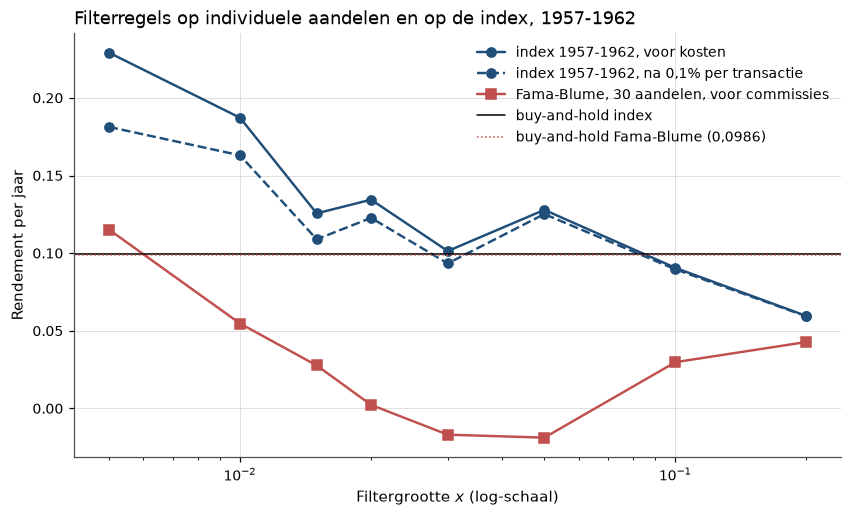

In [10]:
fig, ax = plt.subplots()
ax.plot(ours.index, ours["voor kosten"], "o-", color=hap.plotting.COLORS[0],
        label="index 1957-1962, voor kosten")
ax.plot(ours.index, ours["na 0,1% per transactie"], "o--", color=hap.plotting.COLORS[0],
        label="index 1957-1962, na 0,1% per transactie")
ax.plot(published.index, published["FB voor commissies"], "s-", color=hap.plotting.COLORS[1],
        label="Fama-Blume, 30 aandelen, voor commissies")
ax.axhline(ours["buy-and-hold"].mean(), color="black", lw=1.0, label="buy-and-hold index")
ax.axhline(0.0986, color=hap.plotting.COLORS[1], lw=1.0, ls=":",
           label="buy-and-hold Fama-Blume (0,0986)")
ax.set_xscale("log")
ax.set_title("Filterregels op individuele aandelen en op de index, 1957-1962")
ax.set_xlabel("Filtergrootte $x$ (log-schaal)")
ax.set_ylabel("Rendement per jaar")
ax.legend()
plt.show()

:::{figure} #cel-efficiente-markten-filters
:label: fig-efficiente-markten-filters
:width: 90%

Filterregels in het venster van Fama en Blume. De rode vierkanten zijn hun
gepubliceerde gemiddelden over dertig aandelen (tabel 3, kolom 1), de blauwe
lijnen dezelfde regel op de marktindex. Beide dalen met de filtergrootte en
eindigen rond buy-and-hold; het verschil bij de kleinste filters is de extra
autocorrelatie van de index door niet-synchrone handel. Die zit in de meting,
niet in iets wat men had kunnen kopen.
:::

Nu Alexander. Over 1929–1959 verdiende zijn 5%-filter $36{,}8\%$ per jaar tegen
$3{,}0\%$, en hij concludeerde: "The riddle has been resolved. ... Such a trend
does exist" {cite}`Alexander1961`. Mandelbrot wees erop dat Alexander aannam dat
men precies op het filterniveau kon handelen, terwijl koersen in sprongen bewegen
{cite}`Mandelbrot1963`; in 1964 herrekende Alexander zijn resultaten en bleef er
veel minder over {cite}`Alexander1964`. Een tweede bron van schijnwinst kunnen wij
zichtbaar maken: middeling. Shillers maandprijs is een gemiddelde van dagkoersen,
en Working liet in 1960 zien dat de verschillen van zo'n gemiddelde van een random
walk positief gecorreleerd zijn, asymptotisch met een eerste autocorrelatie van
$0{,}25$ {cite}`Working1960`.

In [11]:
shiller_returns = hap_data.shiller()["price"].pipe(lambda p: p / p.shift(1) - 1).dropna()
french_monthly = hap_data.market_monthly()["Mkt"]

rows = {}
for name, r in [
    ("Shiller maandgemiddelde, 1897-1929", shiller_returns.loc["1897":"1929-09"]),
    ("Shiller maandgemiddelde, 1929-1959", shiller_returns.loc["1929-09":"1959"]),
    ("French maandeinde, 1929-1959", french_monthly.loc["1929-09":"1959"]),
]:
    perf = filter_performance(r, 0.05, periods=12)
    rows[name] = {
        "rho_1 maandrendement": np.log1p(r).autocorr(1),
        "5%-filter voor kosten": perf["voor kosten"],
        "buy-and-hold": perf["buy-and-hold"],
        "voorsprong": perf["voor kosten"] - perf["buy-and-hold"],
        "transacties per jaar": perf["transacties per jaar"],
    }
alexander = pd.DataFrame(rows).T
alexander.round(4)

,rho_1 maandrendement,5%-filter voor kosten,buy-and-hold,voorsprong,transacties per jaar
"Shiller maandgemiddelde, 1897-1929",0.2610,0.0697,0.0606,0.0091,1.4301
"Shiller maandgemiddelde, 1929-1959",0.2995,0.1576,0.0248,0.1328,1.4917
"French maandeinde, 1929-1959",0.1250,0.0387,0.0811,-0.0424,2.1878


Op Shillers maandgemiddelden over 1929–1959 verslaat het 5%-filter buy-and-hold
met dertien procentpunt per jaar ($15{,}8\%$ tegen $2{,}5\%$), bij een eerste
autocorrelatie van $0{,}30$ — dicht bij Workings $0{,}25$. Op de maandeindkoersen
van French over dezelfde jaren blijft hetzelfde filter vier procentpunt achter.
Shillers buy-and-hold zonder dividenden, $2{,}5\%$, ligt dicht bij Alexanders
$3{,}0\%$; over 1897–1929 is de voorsprong op Shillers reeks met één procentpunt
klein. Alexanders $36{,}8\%$ halen wij niet — hij werkte met dagkoersen en met de
bias die Mandelbrot aanwees — maar de les is die van Fama en Blume: een "trend in
de move-dimensie" die alleen in een geconstrueerde reeks bestaat, is een
eigenschap van de meting.

```{admonition} Replicatie
:class: seealso

**Bron.** Michael C. Jensen, *The Performance of Mutual Funds in the Period
1945–1964*, Journal of Finance 1968 {cite}`Jensen1968`.

**Wat.** Tabellen 2 en 4: de intercept $\alpha_j$ in
$R_{jt} - R_{Ft} = \alpha_j + \beta_j(R_{Mt} - R_{Ft}) + u_{jt}$ voor 115 fondsen
op jaardata. Gemiddeld $\hat\alpha = -0{,}011$ na alle kosten (76 negatief, 39
positief; extremen $-0{,}080$ en $0{,}058$), gemiddelde bèta $0{,}840$, en
$-0{,}004$ vóór beheerkosten (67 negatief, 48 positief). Veertien fondsen hadden
$t < -2$.

**Data hier.** Maandkoersen, gecorrigeerd voor uitkeringen, van zeven grote
actieve Amerikaanse aandelenfondsen en het indexfonds VFINX als controle,
1982–2026 (`hap.data.yahoo(...)`); markt en rente van French
(`hap.data.market_monthly()`).

**Verschil met het origineel.** Jensen nam alle fondsen met tien jaar data, op
jaarbasis, tegen de S&P 500. Wij nemen maanddata, de French-markt, en zeven
fondsen die wij kiezen omdat ze *vandaag* groot en bekend zijn: overlevers, met de
bias uit [](#02-05-crsp-tape) in het voordeel van de fondsen. Dit is een
vooruitwijzing; de replicatie op schaal volgt in [](#04-25-industrie).

**Verwachte afwijking.** Het indexfonds moet een alpha hebben van ongeveer min
zijn kosten, binnen enkele tienden van een procent per jaar, met $|t| < 2$. Voor
de actieve fondsen verwachten wij, ondanks de overlevingsbias, geen $t$-waarde
boven $2$ en een gemiddelde alpha binnen één procentpunt van nul.
```

In [12]:
fund_names = {
    "FMAGX": "Fidelity Magellan", "AGTHX": "Growth Fund of America",
    "FCNTX": "Fidelity Contrafund", "PRGFX": "T. Rowe Price Growth Stock",
    "VWNDX": "Vanguard Windsor", "DODGX": "Dodge & Cox Stock",
    "TWCUX": "American Century Ultra", "VFINX": "Vanguard 500 Index (controle)",
}
fund_prices = hap_data.yahoo(list(fund_names), "1980-01-01").resample("ME").last()
fund_returns = (fund_prices / fund_prices.shift(1) - 1).loc["1982":]
factors = hap_data.market_monthly()

rows = {}
for ticker, name in fund_names.items():
    y = (fund_returns[ticker] - factors["RF"].reindex(fund_returns.index)).dropna()
    X = factors["Mkt-RF"].reindex(y.index)
    fit = hap.stats.newey_west(y, X, lags=0)
    rows[name] = {
        "alpha per jaar": 12 * fit.params.iloc[0],
        "t(alpha)": fit.tvalues.iloc[0],
        "beta": fit.params.iloc[1],
        "maanden": int(fit.nobs),
    }
jensen = pd.DataFrame(rows).T
active = jensen.drop(index="Vanguard 500 Index (controle)")
jensen.loc["gemiddelde actieve fondsen"] = active.mean()
jensen.round(3)

,alpha per jaar,t(alpha),beta,maanden
Fidelity Magellan,-0.006,-0.698,1.063,535.0
Growth Fund of America,-0.006,-0.645,0.998,535.0
Fidelity Contrafund,0.014,1.285,0.929,535.0
T. Rowe Price Growth Stock,-0.022,-2.277,1.006,535.0
Vanguard Windsor,-0.006,-0.523,0.920,535.0
Dodge & Cox Stock,0.011,0.889,0.937,535.0
American Century Ultra,-0.006,-0.420,1.211,535.0
Vanguard 500 Index (controle),-0.003,-0.708,0.967,535.0
gemiddelde actieve fondsen,-0.003,-0.341,1.009,535.0


Het indexfonds heeft een alpha van $-0{,}3\%$ per jaar met $t = -0{,}7$: kosten plus
het kleine verschil tussen de S&P 500 en de totale markt. Geen van de zeven actieve
fondsen haalt een $t$-waarde boven $1{,}3$; de hoogste alpha, $1{,}4\%$ voor Fidelity
Contrafund, is niet significant. De gemiddelde alpha is $-0{,}3\%$ per jaar, en
T. Rowe Price Growth Stock blijft significant achter met $t = -2{,}3$. Jensen vond
"very little evidence that any *individual* fund was able to do significantly
better than that which we expected from mere random chance"; zeven overlevers,
veertig jaar later, geven hetzelfde beeld in een steekproef die zo gunstig
mogelijk is gekozen. De standaardfout van een alpha is na vierenveertig jaar
maanddata nog steeds ongeveer één procentpunt per jaar: een beheerder die
werkelijk één procent toevoegt, is na een loopbaan niet van geluk te
onderscheiden. Dat is het 2%-motief in de sterke vorm.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Veel, met een kleine aanname: concurrentie om
informatie maakt voorspelbare winst na kosten onmogelijk. Daaruit volgen de
bijna-nul-autocorrelaties van [](#01-02-bachelier); het falen van filterregels
zodra dividenden en kosten meetellen, dat Fama en Blume aantoonden en dat wij op
de verhandelbare SPY terugzagen met een verlies van zestien procentpunt vóór
kosten; en de ondermaatse prestatie van fondsen, van Jensens $-1{,}1\%$ tot onze
$-0{,}3\%$ voor zeven overlevers. De indeling in drie vormen structureerde twintig
jaar empirisch werk, en de praktische conclusie — een goedkoop indexfonds is
moeilijk te verslaan — werd een industrie.

**Waar het breekt.** Op een logische eigenschap die we hebben bewezen: elk patroon
van voorspelbaarheid heeft een SDF die het rationeel maakt
({prf:ref}`thm-efficiente-markten-elke-sdf`), dus "efficiëntie" zonder model
verbiedt niets. Het feit dat de spanning zichtbaar maakt, maten we zelf: op de
marktindex verdiende het 0,5%-filter tussen 1957 en 1962 $22{,}9\%$ per jaar tegen
$10{,}0\%$ voor buy-and-hold, en $18{,}1\%$ na clearingkosten. En de simulatie liet
zien dat een rationele variatie van $3{,}6$ procentpunt in het verwachte rendement
zeventig jaar data vraagt voor een halve kans op detectie. Toetsen van efficiëntie
zijn zwak als ze niets vinden en dubbelzinnig als ze iets vinden; Jensens
themanummer van 1978 kondigde daarom "a coming mini-revolution in the field" aan
{cite}`Jensen1978`.

**Risico of vergissing?** De Chicago-lezing van het filterfeit: het is een
meetartefact van niet-synchrone handel dat verdwijnt zodra men een verhandelbaar
instrument gebruikt, en voor zover rendementen wél voorspelbaar zijn, is dat een
tijdvariërende prijs van risico, zoals na slecht nieuws in het toy-voorbeeld. De
Yale-lezing: informatie verspreidt zich langzaam over dun verhandelde aandelen,
en kosten waren precies de *limits of arbitrage* (de grenzen aan wat
arbitrageurs kunnen wegwerken, doordat handelen geld en risico kost) die de
vergissing lieten bestaan, tot arbitrage haar na 1990 wegnam. Voor de fondsen
idem: Chicago ziet een efficiënte markt, Grossman en Stiglitz een evenwicht
waarin beheerders bruto iets vinden en het als kosten inleveren. Scheiden zou
kunnen met data over wie wanneer tegen welke prijs kon handelen, en met een
onafhankelijk gemeten $m_{t+1}$; het eerste ontbreekt voor de jaren zestig, het
tweede tot op vandaag. Santa-Clara's praktijkles past op beide lezingen: wie het
filter handelde, dacht iets te weten wat de prijs niet wist — en betaalde de
makelaar.

**Wat er daarna kwam.** Na prijzen kwam de vraag hoe snel prijzen reageren op
*publiek nieuws* zoals splits en winstcijfers; daarvoor ontwikkelden Fama, Fisher,
Jensen en Roll in 1969 de event study: zie [](#02-07-event-studies).

## Oefeningen

:::{exercise}
:label: ex-efficiente-markten-1

**Het Samuelson-effect.** Laat de spotprijs een AR(1) rond $\bar S$ volgen:
$S_{t+1} - \bar S = \phi(S_t - \bar S) + \varepsilon_{t+1}$, met $0 < \phi < 1$ en
$\Var(\varepsilon) = \sigma^2$.

1. Leid $F_t = \E_t[S_T]$ af en toon aan dat
   $\Var(F_{t+1} - F_t) = \phi^{2(T-t-1)}\sigma^2$.
2. Bereken voor $\phi = 0{,}5$ en $T = 12$ de verhouding tussen de variantie van de
   termijnprijsverandering in de laatste en in de eerste periode, en controleer met
   de simulatie uit de theoriesectie.
:::

:::{solution} ex-efficiente-markten-1
:class: dropdown

**(1)** Herhaald substitueren geeft
$S_T - \bar S = \phi^{T-t}(S_t - \bar S) + \sum_{j=1}^{T-t}\phi^{T-t-j}\varepsilon_{t+j}$,
dus $F_t = \bar S + \phi^{T-t}(S_t - \bar S)$ en
$F_{t+1} - F_t = \phi^{T-t-1}\left[(S_{t+1} - \bar S) - \phi(S_t - \bar S)\right]
= \phi^{T-t-1}\varepsilon_{t+1}$. Het gemiddelde $\bar S$ valt eruit: het zit al
in de prijs.

**(2)**

In [13]:
changes = np.diff(futures, axis=1)
ratio_theory = phi ** 0 / phi ** (2 * (horizon - 1))
ratio_sim = changes[:, -1].var() / changes[:, 0].var()
print(f"Var laatste / Var eerste, theorie   : {ratio_theory:,.0f}")
print(f"Var laatste / Var eerste, simulatie : {ratio_sim:,.0f}")

Var laatste / Var eerste, theorie   : 4,194,304
Var laatste / Var eerste, simulatie : 4,208,815


De verhouding is $\phi^{-22} = 2^{22} \approx 4{,}2$ miljoen, en de simulatie komt
tot op enkele promille uit; omdat [](#eq-efficiente-markten-ar1) exact is, is de
enige ruis die van de geschatte varianties. Twee termijnmarkten met dezelfde
onderliggende dynamiek kunnen dus ordes van grootte verschillen in gemeten
volatiliteit, alleen door de looptijd. De oefening laat zien dat Samuelsons
stelling niet alleen zegt *dat* termijnprijzen onvoorspelbaar zijn, maar ook
toetsbaar voorspelt hoe hun onzekerheid in de tijd verloopt.
:::

:::{exercise}
:label: ex-efficiente-markten-2

**Hoeveel SDF-volatiliteit kost voorspelbaarheid?** Neem het toy-voorbeeld met een
SDF $m = 1 - k$ als het meezit en $m = 1 + k$ als het tegenzit, in beide perioden.

1. Toon aan dat $p_1(\text{slecht}) = 80 - 20k$ en $p_1(\text{goed}) = 120 - 20k$.
2. Bepaal $k$ zodat het verwachte rendement na slecht nieuws $10\%$ is. Wat is het
   dan na goed nieuws, en op $t = 0$?
3. Voor welke $k$ ontstaat er arbitrage, en wat is dan de grootste voorspelbaarheid
   die deze economie rationeel kan hebben?
:::

:::{solution} ex-efficiente-markten-2
:class: dropdown

**(1)** $p_1(\text{slecht}) = \tfrac12(1-k)100 + \tfrac12(1+k)60 = 80 - 20k$ en
$p_1(\text{goed}) = \tfrac12(1-k)140 + \tfrac12(1+k)100 = 120 - 20k$: de
risicocorrectie is in beide toestanden $20k$, want de spreiding is in beide 40.

**(2)** $80/(80 - 20k) = 1{,}10$ geeft $k = 4/11 \approx 0{,}364$.

In [14]:
k = 4 / 11
m_k = (1 - k, 1 + k)
p1_k = {s: price(*dividends[s], m=m_k) for s in dividends}
p0_k = price(p1_k["goed"], p1_k["slecht"], m=m_k)
pd.Series(
    {
        "k": k,
        "p_1 (goed)": p1_k["goed"],
        "p_1 (slecht)": p1_k["slecht"],
        "p_0": p0_k,
        "E_1[R_2] - 1 na goed": 120 / p1_k["goed"] - 1,
        "E_1[R_2] - 1 na slecht": 80 / p1_k["slecht"] - 1,
        "E_0[R_1] - 1": 0.5 * (p1_k["goed"] + p1_k["slecht"]) / p0_k - 1,
        "SD(m) / E(m)": k,
    }
).round(4)

k                           0.3636
p_1 (goed)                112.7273
p_1 (slecht)               72.7273
p_0                        85.4545
E_1[R_2] - 1 na goed        0.0645
E_1[R_2] - 1 na slecht      0.1000
E_0[R_1] - 1                0.0851
SD(m) / E(m)                0.3636
dtype: float64

Na goed nieuws is het verwachte rendement $6{,}45\%$, op $t = 0$ $8{,}51\%$. Om dat
verschil rationeel te maken is een SDF nodig met een standaarddeviatie van $36\%$
per periode — de verhouding $\SD(m)/\E(m)$ uit
{prf:ref}`thm-efficiente-markten-elke-sdf`.

**(3)** Bij $k \ge 1$ is $m \le 0$ als het meezit: een claim die alleen dan
uitbetaalt, kost niets, en dat is arbitrage. Voor $k \uparrow 1$ gaat
$p_1(\text{slecht})$ naar 60 en het verwachte rendement na slecht nieuws naar
$33\%$; meer voorspelbaarheid kan geen SDF als risicopremie verklaren. De joint
hypothesis houdt dus niet op bij "elk patroon is rationeel", maar bij "elk patroon
zonder arbitrage" — en bij de vraag of zo'n volatiele SDF geloofwaardig is.
:::

:::{exercise}
:label: ex-efficiente-markten-3

**Break-even kosten en de lange kant.** Fama en Blume rekenden uit dat een
0,5%-filter dat alleen lang gaat bruto $0{,}209$ per jaar verdiende, en na
clearingkosten $0{,}125$.

1. Bereken voor het 0,5%-filter op de index de break-even kosten $c^{*}$ per
   transactie waarbij het filter na kosten precies buy-and-hold oplevert, voor
   1957–1962, 1963–1989 en 1990–2026.
2. Herhaal met een filter dat alleen lang gaat en anders de risicovrije rente van
   French verdient.
3. Wat zeggen de antwoorden over de vraag of dit filter ooit door een belegger te
   incasseren was?
:::

:::{solution} ex-efficiente-markten-3
:class: dropdown

Omdat kosten lineair zijn in het aantal transacties, is
$c^{*} = (\text{voor kosten} - \text{buy-and-hold}) / \text{transacties per jaar}$.

In [15]:
def long_only_performance(returns, rf, x, periods=252):
    """Long when the filter says long, otherwise earn the risk-free rate."""
    held = pd.Series(filter_positions((1 + returns).cumprod(), x), index=returns.index)
    held = held.shift(1).fillna(0.0)
    first = held.ne(0).idxmax()
    long = held.loc[first:].eq(1).astype(float)
    r, f = returns.loc[first:], rf.reindex(returns.index).loc[first:]
    return periods * np.log1p(long * r + (1 - long) * f).mean()


rf_daily = hap_data.market_daily()["RF"]
rows = {}
for name in ["1957-12 t/m 1962-09 (FB)", "1963 t/m 1989", "1990 t/m 2026"]:
    r = periods_daily[name]
    perf = filter_performance(r, 0.005)
    rows[name] = {
        "break-even c* per transactie": (perf["voor kosten"] - perf["buy-and-hold"])
        / perf["transacties per jaar"],
        "lang/short voor kosten": perf["voor kosten"],
        "alleen lang voor kosten": long_only_performance(r, rf_daily, 0.005),
        "buy-and-hold": perf["buy-and-hold"],
    }
pd.DataFrame(rows).T.round(4)

,break-even c* per transactie,lang/short voor kosten,alleen lang voor kosten,buy-and-hold
1957-12 t/m 1962-09 (FB),0.0027,0.2291,0.1773,0.1005
1963 t/m 1989,0.0041,0.3109,0.2398,0.1031
1990 t/m 2026,-0.0016,-0.0084,0.0675,0.1041


Tot 1990 ligt de break-even tussen $0{,}27\%$ en $0{,}41\%$ per transactie: boven de
$0{,}1\%$ clearingkosten van een floor trader, onder de commissie van een gewone
belegger. Na 1990 is $c^{*}$ negatief: het filter verliest al vóór kosten. De
variant die alleen lang gaat, doet het vóór 1990 slechter dan die met shorts
($17{,}7\%$ tegen $22{,}9\%$ in het venster van Fama en Blume) maar beter dan
buy-and-hold; na 1990 ontloopt hij het grootste verlies, maar blijft hij met
$6{,}8\%$ onder de $10{,}4\%$ van buy-and-hold. Het antwoord op (3): toen de
kosten hoog waren, bestond de trend alleen in een index die men niet kon kopen,
en toen men die index kon kopen, bestond de trend niet meer. "Net of all costs"
in Jensens definitie is geen voetnoot, maar het halve argument.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->